# OOP

## 클래스 생성 과 인스턴스 생성 및 인스턴스 메소드 호출

In [1]:
#Class 선언
class Student:
    #인스턴스가 있어야만 호출가능한 Method 생성
    def insa(self):
        print('안녕하세요')
        
    #인스턴스가 있어야만 호출가능한 Method 생성
    def printName(self, name):
        #Method 내부에서 다른 Method 호출
        self.insa()
        print('이름은',name)

#인스턴스 생성
stu = Student()
#바운드 호출
stu.printName("사이버가수 아담")
#언바운드 호출 
Student.printName(stu, "군계")

안녕하세요
이름은 사이버가수 아담
안녕하세요
이름은 군계


## Attribute 생성 및 호출

In [2]:
class Student:
    schoolName = "Korea"

stu1 = Student()
stu2 = Student()

print("stu1의 참조:",id(stu1))
print("stu2의 참조:",id(stu2))
print("===========================")

#schoolName은 Method 외부에 만들어진 것이므로 class 변수가 되고 
#Class 변수는 1개만 만들어서 
#Class와 Class로부터 만들어진 인스턴스 모두가 공유해서 사용
#따라서 아래 3개의 출력문은 모두 동일한 값을 출력

print("Student의 학교:",Student.schoolName)
print("stu1의 학교:",stu1.schoolName)
print("stu2의 학교:",stu2.schoolName)
print("===========================")

#Class를 이용해서 Attribute을 변경하면 Class Attribute이 변경됨
Student.schoolName="Seoul"
print("Student의 학교:",Student.schoolName)
print("stu1의 학교:",stu1.schoolName)
print("stu2의 학교:",stu2.schoolName)
print("===========================")

#인스턴스를 이용해서 Attribute의 값을 수정하면 Class Attribute을 수정하는 것이 아니고
#자신에게 없는 Attribute이면 생성하고 없는 Attribute이면 수정 

stu1.schoolName = "KAIST"
print("Student의 학교:",Student.schoolName)
print("stu1의 학교:",stu1.schoolName)
print("stu2의 학교:",stu2.schoolName)

stu1의 참조: 140434654350736
stu2의 참조: 140434654350832
Student의 학교: Korea
stu1의 학교: Korea
stu2의 학교: Korea
Student의 학교: Seoul
stu1의 학교: Seoul
stu2의 학교: Seoul
Student의 학교: Seoul
stu1의 학교: KAIST
stu2의 학교: Seoul


## Accessor

In [3]:
class Student:
    #Method를 만들 때 첫번째 매개변수는 인스턴스의 참조를 기억하는 self
    def getName(self):
        #인스턴스가 각각 소유하는 name의 값을 리턴
        return self.name

    #매개변수가 2개인 함수
    def setName(self, name):
        #매개변수로 받은 내용을 인스턴스가 각각 소유하는 name에 대입
        self.name = name

#객체 자신의 name에 값을 설정
student1 = Student()
student1.setName('아담')

student2 = Student()
student2.setName('류시아')

#객체 자신의 값을 가져오기 때문에 내용이 다름
print(student1.getName()) 
print(student2.getName())

아담
류시아


## Constructor & Destructor

In [4]:
class Student:
    def getName(self):
        return self.name

    def setName(self, name):
        self.name = name

student1 = Student()
student1.setName('아담')
print(student1.getName())

student2 = Student()
print(student2.getName())

아담


AttributeError: 'Student' object has no attribute 'name'

In [5]:
class Student:
    def getName(self):
        return self.name

    def setName(self, name):
        self.name = name

student1 = Student()
student1.setName('아담')
print(student1.getName())

student2 = Student()
print(student2.getName())

아담


AttributeError: 'Student' object has no attribute 'name'

In [6]:
import time
class Student:
    # 생성자
    def __init__(self, name="사이버가수"):
        print(time.ctime(), "에 인스턴스가 생성되었습니다.")
        self.name = name

    def setName(self, name):
        self.name = name

    def getName(self):
        return self.name

    # 소멸자
    def __del__(self):
        print(time.ctime(), "에 인스턴스가 소멸되었습니다.")

student1 = Student()
student1.setName('아담')
print(student1.getName())

student2 = Student()
print(student2.getName())

#객체의 소멸은 None을 대입해서 retain count를 1감소 시켜서 0을 만들어서 삭제
student1 = None
student2 = None        

Sun Feb 13 09:12:43 2022 에 인스턴스가 생성되었습니다.
아담
Sun Feb 13 09:12:43 2022 에 인스턴스가 생성되었습니다.
사이버가수
Sun Feb 13 09:12:43 2022 에 인스턴스가 소멸되었습니다.
Sun Feb 13 09:12:43 2022 에 인스턴스가 소멸되었습니다.


## 참조 횟수

In [7]:
import sys

student1 = Student()
print(sys.getrefcount(student1))
student1 = None
#아래 문장은 에러
#print(student1.getName())

student2 = Student()
print(sys.getrefcount(student2))
student3 = student2
print(sys.getrefcount(student2))
student2 = None
print(student3.getName())

Sun Feb 13 09:15:17 2022 에 인스턴스가 생성되었습니다.
2
Sun Feb 13 09:15:17 2022 에 인스턴스가 소멸되었습니다.
Sun Feb 13 09:15:17 2022 에 인스턴스가 생성되었습니다.
2
3
사이버가수


## Static Method 와 Class Method

In [8]:
class Student:
    @classmethod
    def cmethod(cls):
        print("Class Method")
        print(cls)

    @staticmethod
    def smethod():
        print("정적 Method")

#클래스를 이용한 메소드
Student.cmethod()
Student.smethod()

#인스턴스를 이용한 메소드
student = Student()
student.cmethod()
student.smethod()

Class Method
<class '__main__.Student'>
정적 Method
Class Method
<class '__main__.Student'>
정적 Method


## __slots__

In [9]:
class Student:
    name = ""
    score = 0

   
student = Student()
student.name = "제시카"
student.score = 90
student.tel = "01031391997"
print(student.tel)

01031391997


In [10]:
class Student:
    __slots__ = ["name", "score"]

student = Student()
student.name = "제시카"
student.score = 90
student.tel = "01031391997"
print(student.tel)

AttributeError: 'Student' object has no attribute 'tel'

## Property

In [11]:
class Student:
    def __init__(self, name, age):
        self.name = name
        self.__age = age

maria = Student('마리아', 20)
maria.name = "Maria"
maria.__age -= 1  # Class 외부에서 비공개 Attribute에 접근하면 에러가 발생함

AttributeError: 'Student' object has no attribute '__age'

In [12]:
class Student:
    def __init__(self, name="noname"):
        self.__name = name

    def setName(self, name):
        print("setter 호출")
        self.__name = name

    def getName(self):
        print("getter 호출")
        return self.__name

    name = property(getName, setName)


stu = Student()
# 아래 문장은 변수를 호출한 것이 아니고 Accessor를 호출한 것
stu.name = "adam"
print(stu.name)

setter 호출
getter 호출
adam


In [13]:
class Student:

    def __init__(self, name="noname"):
        self.__name = name

    @property
    def name(self):
        print("getter 호출")
        return self.__name

    @name.setter
    def name(self, name):
        print("setter 호출")
        self.__name = name

stu = Student()
stu.name = "아담"
print(stu.name)

setter 호출
getter 호출
아담


## 연산자 오버로딩

In [14]:
class Student:
    def __init__(self, name="noname"):
        self.__name = name

    def setName(self, name):
        print("setter 호출")
        self.__name = name

    def getName(self):
        print("getter 호출")
        return self.__name

    def __add__(self, other):
        return self.name + "," +  other.name


stu1 = Student()
stu1.name = "아담"

stu2 = Student()
stu2.name = "류시아"

print(stu1 + stu2)

아담,류시아


In [15]:
class Student:
    def __init__(self, name="noname"):
        self.__name = name

    def setName(self, name):
        print("setter 호출")
        self.__name = name

    def getName(self):
        print("getter 호출")
        return self.__name

    def __str__(self):
        return self.name

stu = Student()
stu.name = "아담"
print(stu)

아담


### 인덱싱

In [45]:
class Square:
    def __init__(self, end):
        self.end = end 
        
    def __len__(self):
        return self.end 
    
    def __getitem__(self, k):
        if type(k) != int:
            raise TypeError('...')
        if k < 0 or self.end <= k:
            raise IndexError('index {} out of range'.format(k))
        return k * k
                
s1 = Square(10)
print(len(s1))
print(s1.__getitem__(4))
print(s1[4])
print(s1[20])

10
16
16


IndexError: index 20 out of range

### 매핑 자료형

In [49]:
class MyDict:
    def __init__(self):
        self.d = {}
    
    def __getitem__(self, k): # key
        return self.d[k]
    
    def __setitem__(self, k, v):
        self.d[k] = v 
    
    def __len__(self):
        return len(self.d)
    
m = MyDict( )
m.__setitem__('night','darkness')
m['day'] = 'light'

print(m['day'])
print(m['night'])
print(len(m))

light
darkness
2


### 싱글톤 구현

In [55]:
class Singleton:
    __instance = None # 유일한 객체를 저장하기 위한 클래스 변수
    
    def __new__(cls, *args, **kwargs):
        if cls.__instance is None:
            # 새로운 객체를 생성한다.
            cls.__instance = object.__new__(cls, *args, **kwargs)
        return cls.__instance

class Sub(Singleton): # 싱글톤으로부터 상속받는다. 
    pass
        
s1 = Sub( )
s2 = Sub( )
s1 is s2

True

# Inheritance

## 단일 상속

In [16]:
class Person:
    def greeting(self):
        print('안녕하세요.')
 
class Student(Person):
    def study(self):
        print('공부하기')
 
student = Student()
student.greeting()    # 기반 Class Person의 Method 호출
student.study()       # 파생 Class Student에 추가한 study Method

안녕하세요.
공부하기


## 상위 클래스의 메소드 호출

In [17]:
class Person:
    def __init__(self):
        print('Person __init__')
        self.hello = '안녕하세요.'
        
class Student(Person):
    def __init__(self):
        print('Student __init__')
        self.school = '파이썬 학교'
        
student = Student()
print(student.school)
print(student.hello)    # 기반 Class의 Attribute을 출력하려고 하면 에러가 발생함

Student __init__
파이썬 학교


AttributeError: 'Student' object has no attribute 'hello'

In [18]:
class Person:
    def __init__(self):
        print('Person __init__')
        self.hello = '안녕하세요.'
 
class Student(Person):
    def __init__(self):
        print('Student __init__')
        super().__init__()                # super()로 기반 Class의 Method 호출
        self.school = '파이썬 학교'
 
student = Student()
print(student.school)
print(student.hello) 

Student __init__
Person __init__
파이썬 학교
안녕하세요.


## Method Overriding

In [19]:
class Person:
    def greeting(self):
        print('안녕하세요.')

class Student(Person):
    def greeting(self):
        super().greeting()
        print('반갑습니다.')

student = Student()
student.greeting()

안녕하세요.
반갑습니다.


## 다중 상속

In [20]:
class Base1:
    def __init__(self):
        print('첫번째 상위 클래스의 초기화 메소드')
        
    def method(self):
        print('첫번째 상위 클래스의 메소드')

class Base2:
    def __init__(self):
        print('두번째 상위 클래스의 초기화 메소드')
        
    def method(self):
        print('두번째 상위 클래스의 메소드')

class Derived(Base1, Base2):
    def __init__(self):
        #첫번째 상위 클래스의 초기화 메소드
        super().__init__()
        #두번째 상위 클래스의 초기화 메소드
        super(Base1, self).__init__()
        print('하위 클래스의 초기화 메소드')
        
    def method(self):
        #첫번째 상위 클래스의 method() 호출
        super().method()
        #두번째 상위 클래스의 method() 호출
        super(Base1, self).method()
        print('하위 클래스의 메소드')
        
drived = Derived()
print()
drived.method()

첫번째 상위 클래스의 초기화 메소드
두번째 상위 클래스의 초기화 메소드
하위 클래스의 초기화 메소드

첫번째 상위 클래스의 메소드
두번째 상위 클래스의 메소드
하위 클래스의 메소드


## 추상 클래스

In [21]:
from abc import abstractmethod
from abc import ABCMeta

class StudentBase(metaclass=ABCMeta):
    @abstractmethod
    def study(self):
        pass
    @abstractmethod
    def go_to_school(self):
        pass
    
    def greeting(self):
        print("Hello")
        
        
class Student(StudentBase):
    def study(self):
        print('공부하기')
        
    def go_to_school(self):
        print("학교가기")
 
student = Student()
student.study()


공부하기


In [22]:
class ChineseRestaurant(metaclass=ABCMeta):
    @abstractmethod
    def jajangmyeon(self):
        pass
    
class Magnoliaceae(ChineseRestaurant):
        pass

magnoliaceae = Magnoliaceae()

TypeError: Can't instantiate abstract class Magnoliaceae with abstract methods jajangmyeon

In [23]:
class ChineseRestaurant(metaclass=ABCMeta):
    @abstractmethod
    def jajangmyeon(self):
        pass
    
class Magnoliaceae(ChineseRestaurant):
    def jajangmyeon(self):
        print('이연복이 만든 짜장면')
        
magnoliaceae = Magnoliaceae()
magnoliaceae.jajangmyeon()

이연복이 만든 짜장면


# 파이썬의 특별한 기능

## Delegation

In [24]:
class Delegation:
    def __init__(self, data):
        self.data = data

    def __getattr__(self, name):
        print(name + " 호출")
        #self.data 의 count Method 호출
        return getattr(self.data, name)

instance = Delegation([100,200,300,200,200])
print(instance.count(200))

count 호출
3


## Iterator

In [25]:
li = [1, 2, 3]
it = li.__iter__()
#iterator 출력하기
print(it)
print(it.__next__())
print(it.__next__())
print(it.__next__())
print(it.__next__())

1
2
3


StopIteration: 

In [26]:
class IteratorImpl:
    def __init__(self, stop):
        self.current = 0    # 현재 숫자 유지, 0부터 지정된 숫자 직전까지 반복
        self.stop = stop    # 반복을 끝낼 숫자
 
    def __iter__(self):
        return self         # 현재 인스턴스를 반환
 
    def __next__(self):
        if self.current < self.stop:    # 현재 숫자가 반복을 끝낼 숫자보다 작을 때
            r = self.current            # 반환할 숫자를 변수에 저장
            self.current += 1           # 현재 숫자를 1 증가시킴
            return r                    # 숫자를 반환
        else:                           # 현재 숫자가 반복을 끝낼 숫자보다 크거나 같을 때
            raise StopIteration         # 예외 발생
 
for i in IteratorImpl(3):
    print(i, end=' ')

0 1 2 

In [27]:
study = ['파이썬', '자료구조', '알고리즘', '웹 프로그래밍', '데이터 분석']
for idx, subject in enumerate(study):
    print(idx, ':', subject)

0 : 파이썬
1 : 자료구조
2 : 알고리즘
3 : 웹 프로그래밍
4 : 데이터 분석


## Generator

In [28]:
def gen():
    yield 1
    yield 2
    yield 3
 
# Generator 인스턴스
g = gen()
print(type(g))  # <class 'generator'>

# for 루프 사용 가능
for x in g:
    print(x)

<class 'generator'>
1
2
3


In [29]:
def reverse(data):
    for idx in range(len(data)-1, -1, -1):
        yield data[idx]

for ch in reverse('Teacher'):
    print(ch)

r
e
h
c
a
e
T


In [30]:
def upper_generator(x): 
    for i in x:
        yield i.upper() # 함수의 반환값을 바깥으로 전달

study = ['Python', 'DataStructure', 'Algorithm', 'Web_Programming', 'Data_Analysis']

for i in upper_generator(study): 
    print(i)

PYTHON
DATASTRUCTURE
ALGORITHM
WEB_PROGRAMMING
DATA_ANALYSIS


## coroutine

In [31]:
def add(a, b):
    c = a + b    # add 함수가 끝나면 변수와 계산식은 사라짐
    print(c)
    print('add 함수')
 
def calc():
    add(1, 2)    # add 함수가 끝나면 다시 calc 함수로 돌아옴
    print('calc 함수')
 
calc()

3
add 함수
calc 함수


In [69]:
def tot_coroutine():
    tot = 0
    while True:        # coroutine을 계속 유지하기 위해 무한 루프 사용
        x = (yield)    # coroutine 바깥에서 값을 받아옴
        tot = tot + x
        print('현재까지의 합:', tot)
 
co = tot_coroutine()
next(co)      # coroutine 안의 yield까지 코드 실행(최초 실행)
 
co.send(1)    # coroutine에 숫자 1을 보냄
co.send(2)    # coroutine에 숫자 2을 보냄
co.send(3)    # coroutine에 숫자 3을 보냄

현재까지의 합: 1
현재까지의 합: 3
현재까지의 합: 6


In [70]:
def tot_coroutine():
    total = 0
    while True:
        x = (yield total)    # coroutine 바깥에서 값을 받아오면서 바깥으로 값을 전달
        total += x
 
co = tot_coroutine()
print(next(co))      # 0: coroutine 안의 yield까지 코드를 실행하고 coroutine에서 나온 값 출력
 
print(co.send(1))    # 1: coroutine에 숫자 1을 보내고 coroutine에서 나온 값 출력
print(co.send(2))    # 3: coroutine에 숫자 2를 보내고 coroutine에서 나온 값 출력
print(co.send(3))    # 6: coroutine에 숫자 3을 보내고 coroutine에서 나온 값 출력

0
1
3
6


In [71]:
def number_coroutine():
    try:
        while True:
            x = (yield)
            print(x, end=' ')
    except GeneratorExit:    # coroutine이 종료 될 때 GeneratorExit 예외 발생
        print()
        print('coroutine 종료')
 
co = number_coroutine()
next(co)
 
for i in range(20):
    co.send(i)
 
co.close()

0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 
coroutine 종료


## Decorator

In [72]:
def aop(func):                             # 호출할 함수를 매개변수로 받음
    def wrapper():                           # 호출할 함수를 감싸는 함수
        print(func.__name__, '함수 시작')    # __name__으로 함수 이름 출력
        func()                               # 매개변수로 받은 함수를 호출
        print(func.__name__, '함수 끝')
    return wrapper                           # wrapper 함수 반환
 
@aop
def hello():
    print('hello')

hello()

hello 함수 시작
hello
hello 함수 끝


In [73]:
def aop(func):          # 호출할 함수를 매개변수로 받음
    def wrapper(a):    # 호출할 함수의 매개변수와 똑같이 지정
        r = func(a)    # func에 매개변수를 저장해서 호출하고 반환값을 변수에 저장
        print('결과를 리턴하기 전에 작성했으므로 먼저 수행됩니다.')    # 매개변수와 반환값 출력
        return r          # func의 반환값을 반환
    return wrapper        # wrapper 함수 반환
 
@aop             # @데코레이터
def summary(n):      
    s = 0
    for i in range(n+1):
        s = s + i
    return s    #반환
 
print(summary(20))

결과를 리턴하기 전에 작성했으므로 먼저 수행됩니다.
210


In [74]:
def is_multiple(x):              # 데코레이터가 사용할 매개변수를 지정
    def real_decorator(func):    # 호출할 함수를 매개변수로 받음
        def wrapper(a, b):       # 호출할 함수의 매개변수와 똑같이 지정
            r = func(a, b)       # func을 호출하고 반환값을 변수에 저장
            if r % x == 0:       # func의 반환값이 x의 배수인지 확인
                print('{0}의 반환값은 {1}의 배수입니다.'.format(func.__name__, x))
            else:
                print('{0}의 반환값은 {1}의 배수가 아닙니다.'.format(func.__name__, x))
            return r             # func의 반환값을 반환
        return wrapper           # wrapper 함수 반환
    return real_decorator        # real_decorator 함수 반환
 
@is_multiple(3)     # @데코레이터(인수)
def add(a, b):
    return a + b
 
print(add(10, 20))
print(add(2, 5))

add의 반환값은 3의 배수입니다.
30
add의 반환값은 3의 배수가 아닙니다.
7


# 패키지

## 모듈을 가져오는 순서

In [75]:
import sys
for path in sys.path:
    print(path)

/Users/adam/Documents/lecture/PYTHON/1.Basic
/Users/adam/opt/anaconda3/lib/python38.zip
/Users/adam/opt/anaconda3/lib/python3.8
/Users/adam/opt/anaconda3/lib/python3.8/lib-dynload

/Users/adam/.local/lib/python3.8/site-packages
/Users/adam/opt/anaconda3/lib/python3.8/site-packages
/Users/adam/opt/anaconda3/lib/python3.8/site-packages/aeosa
/Users/adam/opt/anaconda3/lib/python3.8/site-packages/locket-0.2.1-py3.8.egg
/Users/adam/.local/lib/python3.8/site-packages/IPython/extensions
/Users/adam/.ipython


## 모듈 정보

In [40]:
# 적재된 모듈 이름 확인
import sys
from math import sin

print(type(sys.modules))
print()
#print('\n'.join(sys.modules.keys()))

print()
print(sin.__module__)

print()
a = 1
current_module = sys.modules[__name__] # 현재 모듈 얻어내기
print(getattr (current_module, 'a')) # 현재 모듈에서 a의 값 얻어내기

<class 'dict'>


math

1


## 모듈 가져오기

In [76]:
import sys
import mymath

#앞에서 만든 파일 경로 추가
sys.path.append("./")
print(mymath.mypi)
print(mymath.area(5))

3.14
78.5


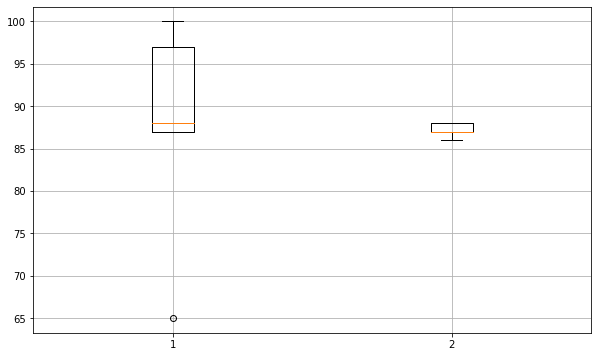

In [77]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10,6))
plt.boxplot(([100, 87, 97, 65, 88], [87,88,86,87,88]))
plt.grid()
plt.show()
fig.savefig("graph.png")

In [79]:
import folium
m = folium.Map(location=[37.572656, 126.973304], zoom_start=15)
folium.Marker(location=[37.572656, 126.973304], popup="KB 국민카드",
             icon=folium.Icon(icon='cloud')).add_to(m)
folium.Marker(location=[37.569027, 126.987279], popup="메가IT",
             icon=folium.Icon(color='red')).add_to(m)
m
m.save("map.html")